<a href="https://colab.research.google.com/github/idarwati/Health-Data-Analytics-Portfolio/blob/Supervised-Unsupervised-Reinforcement/Public_Health_Data_Science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

# 1. Tentukan nama folder utama dan sub-folder
main_folder = "Public-Health-Data-Science-Portfolio"
sub_folders = [
    "1_Prediction_Supervised",
    "2_Segmentation_Unsupervised",
    "3_Optimization_Reinforcement"
]

# 2. Buat Folder Utama
# Pastikan baris 'if' di bawah ini menempel rata kiri (tidak ada spasi di depannya)
if not os.path.exists(main_folder):
    os.makedirs(main_folder)
    print(f"✅ Folder '{main_folder}' berhasil dibuat.")
else:
    print(f"ℹ️ Folder '{main_folder}' sudah ada.")

# 3. Buat Sub-folder
# Baris 'for' juga harus rata kiri
for sub in sub_folders:
    path = os.path.join(main_folder, sub)

    # Baris di bawah ini WAJIB menjorok ke dalam (biasanya 4 spasi atau 1 tab)
    if not os.path.exists(path):
        os.makedirs(path)
        print(f"   📂 Sub-folder '{sub}' berhasil dibuat.")

        # Buat file README kosong
        with open(os.path.join(path, "README.md"), "w") as f:
            f.write(f"# Proyek: {sub}\n\nDeskripsi proyek.")
    else:
        print(f"   ℹ️ Sub-folder '{sub}' sudah ada.")

print("\n🎉 Selesai! Cek panel folder di sebelah kiri.")

ℹ️ Folder 'Public-Health-Data-Science-Portfolio' sudah ada.
   ℹ️ Sub-folder '1_Prediction_Supervised' sudah ada.
   ℹ️ Sub-folder '2_Segmentation_Unsupervised' sudah ada.
   ℹ️ Sub-folder '3_Optimization_Reinforcement' sudah ada.

🎉 Selesai! Cek panel folder di sebelah kiri.


#Supervised Learning (Prediksi)

✅ Data Pasien Berhasil Dibuat!
   Usia  TekananDarah  Kolesterol  RiwayatKeluarga  SakitJantung
0    68           158         241                1             0
1    58           101         207                1             0
2    44           101         332                0             0
3    72           153         239                0             0
4    37           100         266                1             0


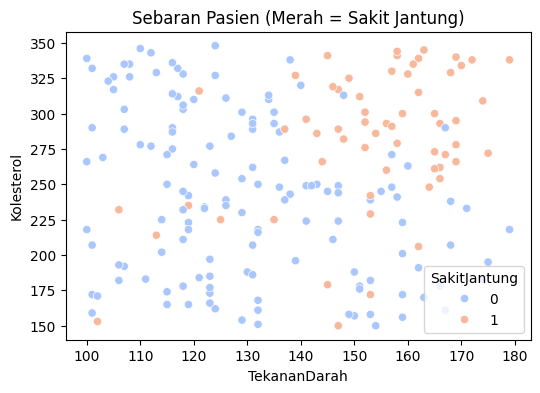


🤖 Model sedang belajar pola dari data...

📊 AKURASI MODEL: 82.50%
------------------------------
Laporan Detail:
              precision    recall  f1-score   support

           0       0.88      0.85      0.87        27
           1       0.71      0.77      0.74        13

    accuracy                           0.82        40
   macro avg       0.80      0.81      0.80        40
weighted avg       0.83      0.82      0.83        40


🏥 SIMULASI DIAGNOSA PASIEN BARU
------------------------------
Data Pasien: 
 Usia  TekananDarah  Kolesterol  RiwayatKeluarga
   55           160         280                1

🔮 Hasil Prediksi AI: RISIKO TINGGI (Sakit)
⚠️ Tingkat Keyakinan Model: 68.50%


In [ ]:
# ==========================================
# MODUL 1: SUPERVISED LEARNING (PREDIKSI)
# Kasus: Deteksi Risiko Penyakit Jantung
# Algoritma: Logistic Regression
# ==========================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. MEMBUAT DATASET DUMMY (SIMULASI)
# Kita buat data 200 pasien secara acak agar Anda tidak perlu upload file
np.random.seed(42) # Agar hasil acak kita sama

n_pasien = 200
data = {
    'Usia': np.random.randint(30, 75, n_pasien),
    'TekananDarah': np.random.randint(100, 180, n_pasien),
    'Kolesterol': np.random.randint(150, 350, n_pasien),
    'RiwayatKeluarga': np.random.randint(0, 2, n_pasien) # 0: Tidak, 1: Ya
}
df = pd.DataFrame(data)

# Buat kolom Target (SakitJantung) berdasarkan logika sederhana (untuk latihan)
# Jika Tensi > 140 DAN Kolesterol > 250, kemungkinan besar sakit (1)
df['SakitJantung'] = np.where((df['TekananDarah'] > 140) & (df['Kolesterol'] > 250), 1, 0)

# Tambahkan sedikit 'noise' (kesalahan acak) agar data terlihat realistis/tidak sempurna
noise_indices = np.random.choice(n_pasien, 20, replace=False)
df.loc[noise_indices, 'SakitJantung'] = 1 - df.loc[noise_indices, 'SakitJantung']

print("✅ Data Pasien Berhasil Dibuat!")
print(df.head()) # Tampilkan 5 data teratas

# 2. VISUALISASI DATA
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='TekananDarah', y='Kolesterol', hue='SakitJantung', palette='coolwarm')
plt.title('Sebaran Pasien (Merah = Sakit Jantung)')
plt.show()

# 3. SPLIT DATA (LATIH & UJI)
X = df[['Usia', 'TekananDarah', 'Kolesterol', 'RiwayatKeluarga']] # Fitur
y = df['SakitJantung'] # Target

# Bagi data: 80% untuk belajar (Train), 20% untuk ujian (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. MELATIH MODEL (TRAINING)
model = LogisticRegression()
model.fit(X_train, y_train)
print("\n🤖 Model sedang belajar pola dari data...")

# 5. EVALUASI MODEL
y_pred = model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)

print(f"\n📊 AKURASI MODEL: {akurasi * 100:.2f}%")
print("-" * 30)
print("Laporan Detail:")
print(classification_report(y_test, y_pred))

# 6. SIMULASI PREDIKSI PASIEN BARU
# Mari kita coba masukkan data pasien baru untuk melihat prediksi AI
print("\n🏥 SIMULASI DIAGNOSA PASIEN BARU")
print("-" * 30)

pasien_baru = pd.DataFrame({
    'Usia': [55],
    'TekananDarah': [160],  # Tensi tinggi
    'Kolesterol': [280],    # Kolesterol tinggi
    'RiwayatKeluarga': [1]  # Ada riwayat
})

prediksi_baru = model.predict(pasien_baru)
probabilitas = model.predict_proba(pasien_baru)[0][1] # Peluang sakit (0-1)

print(f"Data Pasien: \n{pasien_baru.to_string(index=False)}")
print(f"\n🔮 Hasil Prediksi AI: {'RISIKO TINGGI (Sakit)' if prediksi_baru[0]==1 else 'SEHAT (Aman)'}")
print(f"⚠️ Tingkat Keyakinan Model: {probabilitas * 100:.2f}%")

#Unsupervised Learning

✅ Data Fisik Pasien Siap (Tanpa Label Penyakit)
         BMI   GulaDarah
0  21.993428   93.240840
1  20.723471   86.149177
2  22.295377   83.230780
3  24.046060   96.116763
4  20.531693  100.309995


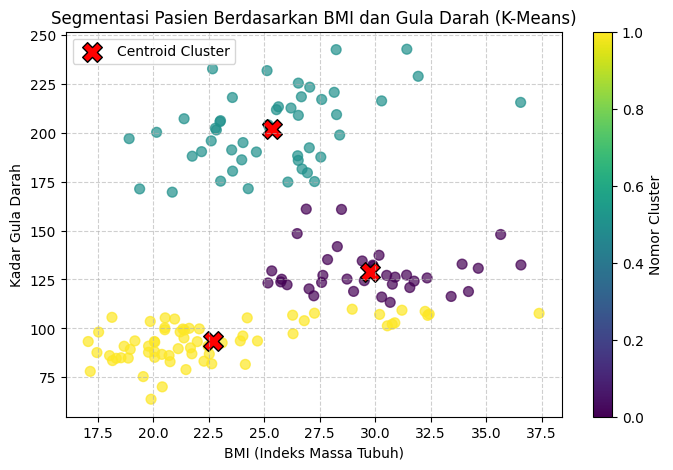


🔍 ANALISIS KLUSTER:
                     BMI   GulaDarah
Cluster_Label                       
0              29.753489  129.056510
1              25.372534  201.722714
2              22.699141   93.736231


In [ ]:
# ==========================================
# MODUL 2: UNSUPERVISED LEARNING (CLUSTERING)
# Kasus: Segmentasi Pasien Puskesmas
# Algoritma: K-Means Clustering
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. MEMBUAT DATASET DUMMY (TANPA LABEL SAKIT/SEHAT)
# Kita hanya punya data fisik: BMI (Berat Badan) & Gula Darah
np.random.seed(42)

# Kita buat 3 kelompok natural secara manual agar visualisasi nanti terlihat jelas
# Kelompok A: Sehat (BMI Normal, Gula Rendah)
kelompok_a = pd.DataFrame({
    'BMI': np.random.normal(21, 2, 50),       # BMI sekitar 21
    'GulaDarah': np.random.normal(90, 10, 50) # Gula sekitar 90
})

# Kelompok B: Risiko Obesitas (BMI Tinggi, Gula Sedang)
kelompok_b = pd.DataFrame({
    'BMI': np.random.normal(30, 3, 50),       # BMI sekitar 30
    'GulaDarah': np.random.normal(120, 15, 50)# Gula sekitar 120
})

# Kelompok C: Risiko Diabetes (BMI Sedang, Gula Sangat Tinggi)
kelompok_c = pd.DataFrame({
    'BMI': np.random.normal(25, 3, 50),       # BMI sekitar 25
    'GulaDarah': np.random.normal(200, 20, 50)# Gula sekitar 200
})

# Gabungkan jadi satu dataset besar yang 'berantakan'
df_cluster = pd.concat([kelompok_a, kelompok_b, kelompok_c], ignore_index=True)

print("✅ Data Fisik Pasien Siap (Tanpa Label Penyakit)")
print(df_cluster.head())

# 2. MENCARI POLA DENGAN K-MEANS
# Kita minta AI membagi data menjadi 3 Cluster (Kelompok)
# Menambahkan n_init untuk menghindari warning pada versi sklearn terbaru
model_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
model_kmeans.fit(df_cluster) # Perhatikan: Kita tidak memasukkan target 'y'!

# Simpan hasil pengelompokan ke dataframe
df_cluster['Cluster_Label'] = model_kmeans.labels_

# 3. VISUALISASI HASIL (PENTING UNTUK UNSUPERVISED)
plt.figure(figsize=(8, 5))

# Plot titik-titik data, diwarnai berdasarkan Cluster yang ditemukan AI
plt.scatter(df_cluster['BMI'], df_cluster['GulaDarah'],
            c=df_cluster['Cluster_Label'], cmap='viridis', s=50, alpha=0.7)

# Tambahkan centroid (pusat cluster) untuk visualisasi yang lebih jelas
plt.scatter(model_kmeans.cluster_centers_[:, 0], model_kmeans.cluster_centers_[:, 1],
            s=200, marker='X', c='red', edgecolor='black', label='Centroid Cluster')

# Beri label sumbu dan judul
plt.title('Segmentasi Pasien Berdasarkan BMI dan Gula Darah (K-Means)')
plt.xlabel('BMI (Indeks Massa Tubuh)')
plt.ylabel('Kadar Gula Darah')
plt.colorbar(label='Nomor Cluster')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 4. INTERPRETASI HASIL (Otomatis)
print("\n🔍 ANALISIS KLUSTER:")
# Hitung rata-rata setiap cluster untuk tahu karakteristiknya
summary = df_cluster.groupby('Cluster_Label').mean()
print(summary)

#Reinforcement Learning

🏥 MEMULAI UJI KLINIS OTOMATIS...

📊 LAPORAN AKHIR UJI KLINIS:
Obat A: Dipilih 38 kali | Tingkat Kesembuhan Terukur: 7.9%
Obat B: Dipilih 447 kali | Tingkat Kesembuhan Terukur: 78.3%
Obat C: Dipilih 15 kali | Tingkat Kesembuhan Terukur: 20.0%

Total Pasien Sembuh: 356 dari 500 pasien.


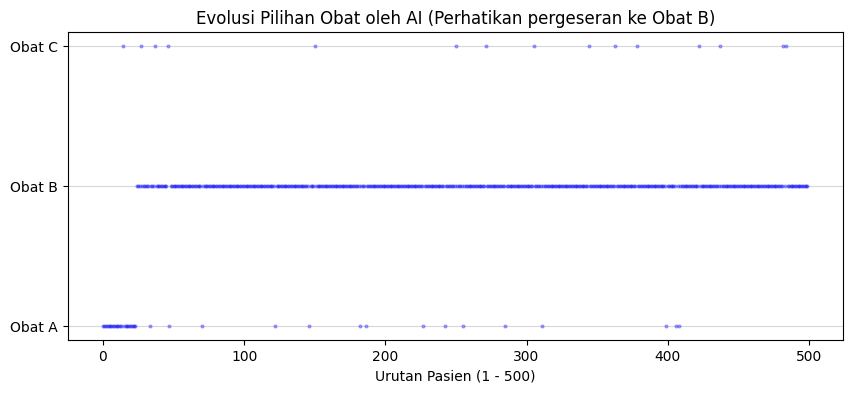

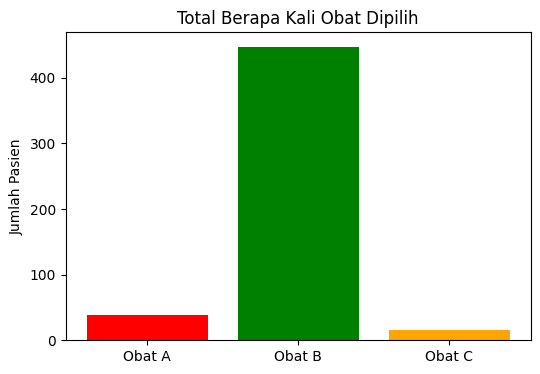

In [ ]:
# ==========================================
# MODUL 3: REINFORCEMENT LEARNING (OPTIMASI)
# Kasus: Multi-Armed Bandit (Uji Klinis Obat)
# Algoritma: Epsilon-Greedy
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

# 1. SIMULASI LINGKUNGAN (RAHASIA ALAM)
# Ini adalah tingkat kemanjuran obat yang SEBENARNYA (AI tidak tahu ini di awal)
# Obat A: 10% sembuh (Obat buruk)
# Obat B: 80% sembuh (Obat sangat ampuh)
# Obat C: 40% sembuh (Obat biasa saja)
true_effectiveness = [0.1, 0.8, 0.4]
nama_obat = ['Obat A', 'Obat B', 'Obat C']

# 2. PARAMETER AI
n_pasien = 500       # Jumlah pasien dalam uji coba
epsilon = 0.1        # 10% waktu AI akan 'iseng' mencoba obat acak (Eksplorasi)
                     # 90% waktu AI akan memilih obat terbaik sejauh ini (Eksploitasi)

# Variabel untuk mencatat hasil belajar
jumlah_dipilih = [0, 0, 0]    # Berapa kali masing-masing obat dipilih
jumlah_sembuh = [0, 0, 0]     # Berapa pasien sembuh per obat
history_pilihan = []          # Rekam jejak pilihan AI

print("🏥 MEMULAI UJI KLINIS OTOMATIS...")

# 3. PROSES BELAJAR (LOOPING PASIEN)
np.random.seed(42)

for i in range(n_pasien):
    # --- Langkah A: AI Memilih Obat ---

    # Cek apakah AI mau eksplorasi (coba-coba) atau eksploitasi (pilih yang terbaik)
    if np.random.random() < epsilon:
        # Eksplorasi: Pilih obat acak
        pilihan = np.random.randint(0, 3)
    else:
        # Eksploitasi: Hitung rata-rata kesembuhan tiap obat sejauh ini
        rata_rata = [s/n if n>0 else 0 for s, n in zip(jumlah_sembuh, jumlah_dipilih)]
        # Pilih obat dengan rata-rata kesembuhan tertinggi
        pilihan = np.argmax(rata_rata)

    # --- Langkah B: Memberikan Obat ke Pasien & Lihat Hasil ---

    # Simulasi: Apakah pasien sembuh? (Berdasarkan 'true_effectiveness')
    # Jika angka acak < efektivitas obat, maka sembuh (1), jika tidak gagal (0)
    hasil = 1 if np.random.random() < true_effectiveness[pilihan] else 0

    # --- Langkah C: Update Otak AI ---
    jumlah_dipilih[pilihan] += 1
    jumlah_sembuh[pilihan] += hasil
    history_pilihan.append(pilihan)

# 4. HASIL AKHIR
print("\n📊 LAPORAN AKHIR UJI KLINIS:")
for i in range(3):
    rate = (jumlah_sembuh[i] / jumlah_dipilih[i] * 100) if jumlah_dipilih[i] > 0 else 0
    print(f"{nama_obat[i]}: Dipilih {jumlah_dipilih[i]} kali | Tingkat Kesembuhan Terukur: {rate:.1f}%")

print(f"\nTotal Pasien Sembuh: {sum(jumlah_sembuh)} dari {n_pasien} pasien.")

# 5. VISUALISASI KEPUTUSAN AI
plt.figure(figsize=(10, 4))
plt.plot(history_pilihan, 'o', markersize=2, alpha=0.3, color='blue')
plt.yticks([0, 1, 2], nama_obat)
plt.xlabel('Urutan Pasien (1 - 500)')
plt.title('Evolusi Pilihan Obat oleh AI (Perhatikan pergeseran ke Obat B)')
plt.grid(True, axis='y', alpha=0.5)
plt.show()

# VISUALISASI FREKUENSI
plt.figure(figsize=(6, 4))
plt.bar(nama_obat, jumlah_dipilih, color=['red', 'green', 'orange'])
plt.title('Total Berapa Kali Obat Dipilih')
plt.ylabel('Jumlah Pasien')
plt.show()